# Short or hold? CNNs vs HBM 

**QRT Challenge Data #167, "Asset Allocation Performance forecasting"** ([challenge page](https://challengedata.ens.fr/challenges/167)).

This notebook tests whether convolutional networks on the 20-day return (and signed-volume) history can beat the hierarchical Bayesian model of `BaysianHierarchicalApproach.ipynb`.

### Imports

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from cnn_utils import *      # RET, VOL, date reconstruction, folds, inputs, group-aware CNNs, training, evaluation

### Read files

In [35]:
X_train = pd.read_csv('X_train.csv',index_col='ROW_ID')
y_train = pd.read_csv('y_train.csv',index_col='ROW_ID')
X_test = pd.read_csv('X_test.csv',index_col='ROW_ID')

In [36]:
X_train["target"] = y_train["target"]      # we attach the next-day return to each row

### Data cleaning & sorting

We clean the data following the same procedure detailed in the companion noteboook [BaysianHierarchicalApproach.ipynb](BaysianHierarchicalApproach.ipynb). The reader can find in the same notebook the hierarchical Bayesian approach we developped and the first data exploration.

The full procedure is now the function `reconstruct_dates` in `cnn_utils.py`. We should have done immediately to be honest. But here we are, and late is better than never. It produces the same stretches as the companion notebook, so the folds below are the same as the HBM's.

In [37]:
X_train = reconstruct_dates(X_train)        # adds PIECE (stretch id) and POS (day within the stretch, forward in time)

shift 1: 2499 candidate links, 2485 pass (z >= 5.0)
shift 2: 1 candidate links, 1 pass (z >= 5.0)
  after k=2: 1 bridges, 54 stretches
shift 3: 0 candidate links, 0 pass (z >= 5.0)
  after k=3: 0 bridges, 54 stretches
shift 4: 1 candidate links, 1 pass (z >= 5.0)
  after k=4: 1 bridges, 53 stretches
shift 5: 0 candidate links, 0 pass (z >= 5.0)
  after k=5: 0 bridges, 53 stretches
shift 1: 17 candidate links, 12 pass (z >= 5.0)
shift 2: 0 candidate links, 0 pass (z >= 5.0)
  after k=2: 0 bridges, 41 stretches
shift 3: 0 candidate links, 0 pass (z >= 5.0)
  after k=3: 0 bridges, 41 stretches
shift 4: 0 candidate links, 0 pass (z >= 5.0)
  after k=4: 0 bridges, 41 stretches
shift 5: 0 candidate links, 0 pass (z >= 5.0)
  after k=5: 0 bridges, 41 stretches
41 stretches | longest 10: [248, 170, 150, 128, 109, 106, 104, 103, 94, 91] | >= 20 dates: 33 | lone dates: 1


### Model Inputs

We want to gauge whether moving to a CNN (with a strong nonlinear learning) can improve upon our HBM, which essentially used only linear features. It might be less interpretable, and we do not expect an hedge gap too big. But it is worth a try. Even a small, but solid, hedge would be good.

In [38]:
folds = make_folds(X_train)                 # GroupKFold over stretches, with a no-overlap check

Fold 0: train = 421,841, validation = 105,232, stretches = 7
Fold 1: train = 421,871, validation = 105,202, stretches = 10
Fold 2: train = 421,275, validation = 105,798, stretches = 8
Fold 3: train = 421,535, validation = 105,538, stretches = 8
Fold 4: train = 421,770, validation = 105,303, stretches = 8


We are in the clear

In [39]:
# Inputs for every fold. All scaling constants (vol floor, signed-volume centre and scale) come from the training part only.
cnn_folds = build_cnn_folds(X_train, folds)

# Class balance (fold 0)
y0 = cnn_folds[0]["train"]["y"] > 0
print(f"positive share (training, fold 0): {y0.mean():.3f}")

Fold 0: train (421841, 20), val (105232, 20), vol_floor = 0.000895856
Fold 1: train (421871, 20), val (105202, 20), vol_floor = 0.000875343
Fold 2: train (421275, 20), val (105798, 20), vol_floor = 0.000894198
Fold 3: train (421535, 20), val (105538, 20), vol_floor = 0.000874752
Fold 4: train (421770, 20), val (105303, 20), vol_floor = 0.000867151
positive share (training, fold 0): 0.507


Now that we have built the training and validation sets, we can move on to the defining the model itself.

### The basic model: a simple CNN

We are going to implement a simple CNN which takes as input the 20-day normalised return history we defined above and used with the HBM, together with the portfolio's group. We are not going to impose complex architectures at this stage. We may do so later but not for now.

Therefore, we simply consider two one-dimensional convolutional layers. The first layer contains 16 learnable filters, in which each filter looks at a local window of three consecutive returns (i.e., learns short-range patterns). On the other hand, the second layer combines these learned patterns into 32 higher-level features. 

Then a layer averages each of the 32 feature maps over the time dimension, thus producing a 32-dimensional representation $h$ of the entire 20-day history. Before the final layer, this representation is modulated by the portfolio's group $g$,

$$ h \;\rightarrow\; h \odot \big(1 + a_g\big) + c_g\,, $$

where $a_g$ and $c_g$ are learned vectors, one pair per group (i.e., we are using feature-wise linear modulation, FiLM). This lets each group weight the same temporal patterns differently by introducing a group-specific slope ($a_g$) and a group-specific offset ($c_g$, i.e., the analogue of the HBM's group drift). Both start at zero, so the model begins *exactly* as a no-group version and only moves away if the data support group differences. Furthermore, each portfolio can add its own deviation on top of its group's $(a_g, c_g)$, with weight decay pulling the deviations towards zero. This assures us that we are dealing with the neural analogue of the HBM's portfolio. A final linear layer maps the modulated representation to a single scalar (we could use a sigmoid to get a probability, but again baby steps).

The resulting architecture is therefore

$$ 20\text{ returns}\;\rightarrow\;\text{local convolutional features}\;\rightarrow\;32\text{-dimensional representation}\;\xrightarrow{\ \text{group FiLM}\ }\;\text{logit}\,.$$

The important point is that the convolutional filters are learned from the data through backpropagation. To wit, no hand-designed feature extraction is imposed on the CNN beyond the initial return normalization.

A final remark on the choice of loss function. We train the model using the binary cross-entropy with logits. Namely, for a single observation ($y$ and logit $z$) the loss is 

$$ \mathcal{L} =-\left[y\log\sigma(z)+(1-y)\log(1-\sigma(z))\right]\,.$$

The choice follows from the fact that the CNN should be explicitly trained to distinguish positive from non-positive next-day returns. This is simply because ultimately the CNN is evaluated here as a *directional classifier*.

In [40]:
print(ReturnCNN(use_groups=True))
print(f"\nParameters: {sum(p.numel() for p in ReturnCNN(use_groups=True).parameters()):,}  "
      f"(without groups: {sum(p.numel() for p in ReturnCNN(use_groups=False).parameters()):,})")

ReturnCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): AdaptiveAvgPool1d(output_size=1)
  )
  (head): Linear(in_features=32, out_features=1, bias=True)
  (film): GroupFiLM(
    (group): Embedding(4, 64)
    (portfolio): Embedding(278, 64)
  )
)

Parameters: 19,713  (without groups: 1,665)


In [ ]:
res_vanilla = run_cv(lambda: ReturnCNN(use_groups=True, n_portfolios=278), cnn_folds)

Fold 3: accuracy = 0.5227, balanced = 0.5199, AUC = 0.5309
Fold 1: accuracy = 0.5216, balanced = 0.5203, AUC = 0.5289


Vanilla CNN + groups
 fold  accuracy  balanced_accuracy      auc
    0  0.515518           0.514535 0.523439
    1  0.521986           0.519695 0.529469
    2  0.518545           0.518174 0.529107
    3  0.521376           0.518596 0.530742
    4  0.523385           0.522267 0.534617
mean: {'accuracy': 0.5202, 'balanced_accuracy': 0.5187, 'auc': 0.5295}
std:  {'accuracy': 0.0031, 'balanced_accuracy': 0.0028, 'auc': 0.004}


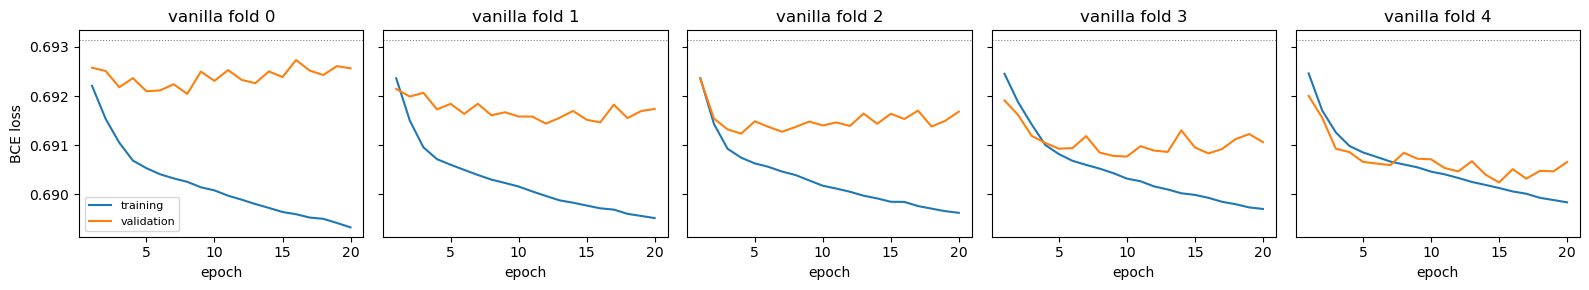

confusion matrix (all folds):
 [[109940 149810]
 [103100 164223]]


In [ ]:
df_vanilla = summarize(res_vanilla, "Vanilla CNN + groups")
plot_losses(res_vanilla, "vanilla")
print("confusion matrix (all folds):\n", sum(r["confusion_matrix"] for r in res_vanilla))

In [ ]:
print(compare_to_hbm({"vanilla CNN": res_vanilla}).to_string(index=False))

               model  CV accuracy  fold sd  vs HBM (pts) folds better  paired t
vanilla CNN + groups       0.5202   0.0031         -0.32          1/5      -2.4


So, no overfitting seem to be really present (althoguh maybe in fold 0, but unsure, it is very noisy). Nonetheless, at this stage we are still below the results of the HBM. But the results are encouraging somewhat. As in, this is really a vanilla CNN and it is doing quite decently!

Can we do better?

### Volume-aware CNN

The original vanilla CNN took the 20-day return history as a single temporal sequence. Here, we extend it by adding the signed-volume history as a second input. We use **separate convolutional branches**. This allows the network to learn temporal patterns in returns and volumes independently before learning how the two signals interact.

In particular, each branch consists of two 1D convolutional layers followed by ReLU activations and adaptive average pooling. The resulting 32-dimensional representations are concatenated and passed through a small fully connected head to predict the next-day return sign. It looks like:

$$\text{return history}\rightarrow \text{CNN}_{R}\rightarrow 32\text{-dimensional representation}$$
$$\text{signed-volume history}\rightarrow \text{CNN}_{V}\rightarrow 32\text{-dimensional representation}$$
$$[\text{representation}_R,\text{representation}_V]\rightarrow \text{MLP}\rightarrow P(r_{t+1}>0).$$

The FiLM step acts on the concatenated 64-dimensional representation, just before the MLP.

In [ ]:
res_volume = run_cv(lambda: ReturnVolumeCNN(use_groups=True), cnn_folds, n_epochs = 10) # we do not need 20 epochs

Fold 4: accuracy = 0.5218, balanced = 0.5217, AUC = 0.5283
Fold 3: accuracy = 0.5138, balanced = 0.5142, AUC = 0.5216
Fold 1: accuracy = 0.5186, balanced = 0.5177, AUC = 0.5243
Fold 0: accuracy = 0.5087, balanced = 0.5069, AUC = 0.5122
Fold 2: accuracy = 0.5133, balanced = 0.5109, AUC = 0.5212


Volume-aware CNN + groups
 fold  accuracy  balanced_accuracy      auc
    0  0.508667           0.506901 0.512233
    1  0.518621           0.517713 0.524339
    2  0.513280           0.510892 0.521220
    3  0.513843           0.514175 0.521572
    4  0.521752           0.521675 0.528313
mean: {'accuracy': 0.5152, 'balanced_accuracy': 0.5143, 'auc': 0.5215}
std:  {'accuracy': 0.0051, 'balanced_accuracy': 0.0058, 'auc': 0.0059}


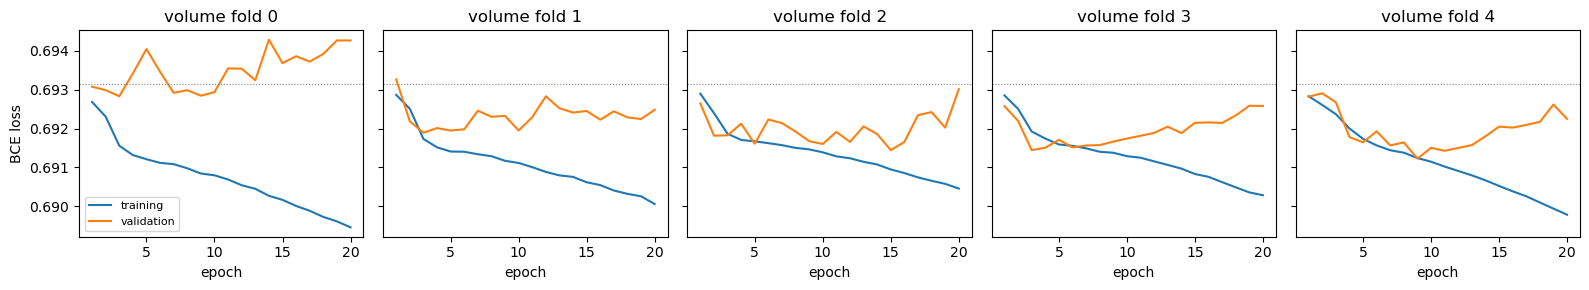

                    model  CV accuracy  fold sd  vs HBM (pts) folds better  paired t
volume-aware CNN + groups       0.5152   0.0051         -0.81          0/5      -4.1


In [ ]:
df_volume = summarize(res_volume, "Volume-aware CNN + groups")
plot_losses(res_volume, "volume")
print(compare_to_hbm({"volume-aware CNN": res_volume}).to_string(index=False))

Looks like we are going backwords now. Maybe adding volume is not the way to go at this stage. Also, and maybe more importantly. We have overfitting!

In the previous run it looked alright. But not here. The volume bit is banished!

### Retaining the lag

We remove the global pooling and flatten the convolutional representation. The convolutional layers still learn local temporal features, but the final MLP receives the full sequence of learned features. Thus, now it will be able to differentiate between a pattern occurring at a recent lag from the same pattern occurring further back in the history.

The architecture is therefore

$$\text{return history}\rightarrow\mathrm{CNN}_R\;\xrightarrow{\ \text{group FiLM}\ }\;\mathrm{Flatten}\rightarrow\text{MLP}\,,$$

where the FiLM step modulates the channels of the feature maps before flattening. Note that we dropped the signed volumes. They did not help. On the countrary, it looked like the volume branch mostly added room to overfit. This model and the next one are therefore built on returns only.

In [ ]:
res_nopool = run_cv(lambda: ReturnCNNNoPool(use_groups=True), cnn_folds, n_epochs=10) # we lower epochs number as 20 is not needed

Fold 4: accuracy = 0.5116, balanced = 0.5115, AUC = 0.5146
Fold 3: accuracy = 0.5089, balanced = 0.5070, AUC = 0.5105
Fold 0: accuracy = 0.5092, balanced = 0.5088, AUC = 0.5125
Fold 2: accuracy = 0.5113, balanced = 0.5114, AUC = 0.5150
Fold 1: accuracy = 0.5076, balanced = 0.5080, AUC = 0.5092


No-pool CNN + groups (returns only)
 fold  accuracy  balanced_accuracy      auc
    0  0.509161           0.508767 0.512501
    1  0.507614           0.508022 0.509205
    2  0.511267           0.511399 0.515019
    3  0.508888           0.506971 0.510517
    4  0.511590           0.511450 0.514580
mean: {'accuracy': 0.5097, 'balanced_accuracy': 0.5093, 'auc': 0.5124}
std:  {'accuracy': 0.0017, 'balanced_accuracy': 0.002, 'auc': 0.0025}


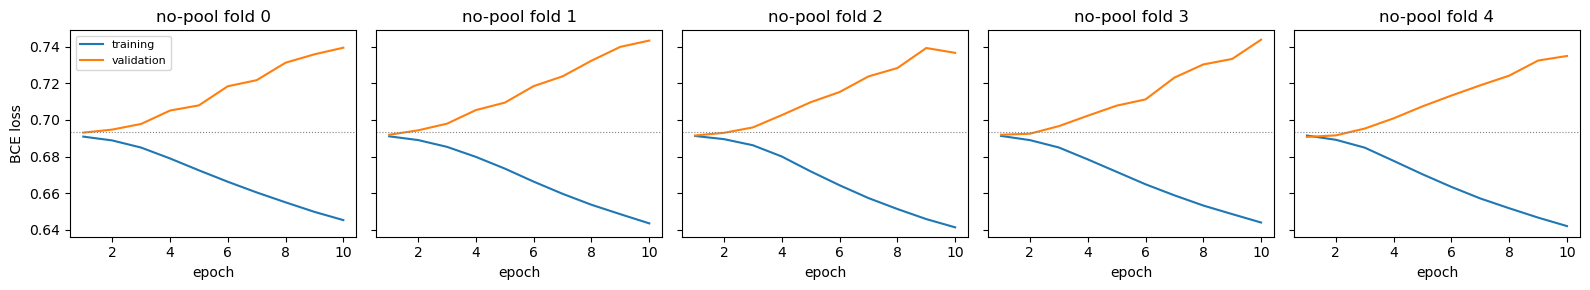

                     model  CV accuracy  fold sd  vs HBM (pts) folds better  paired t
No-pool CNN (returns only)       0.5097   0.0017         -1.36          0/5     -10.7


In [ ]:
df_nopool = summarize(res_nopool, "No-pool CNN + groups (returns only)")
plot_losses(res_nopool, "no-pool")
print(compare_to_hbm({"No-pool CNN (returns only)": res_nopool}).to_string(index=False))

Yeah, no, no, NO. 

Overfitting like crazy. We are not doing this. The reuslts are obviosly nonsense.

### Multi-scale temporal convolutions

The previous pooled CNN used only $3$-lag convolutional filters in the return branch. However, we migth want the CNN to detect patterns at several temporal scales. Therefore, we now start using parallel convolutions with kernel sizes $2$, $3$, and $5$.

Thus, the network learns short-, intermediate-, and longer-range temporal features. The outputs are concatenated and globally average-pooled. We saw above that not doing that just leads to overfitting. Aside from the change in kernels we now have the same architecture as the vanilla CNN, with returns only (no volumes, for the reason given above) and a small MLP head.

As per usual, the FiLM step acts on the pooled 32-dimensional representation.

In [ ]:
res_multiscale = run_cv(lambda: MultiScaleReturnCNN(use_groups=True), cnn_folds, n_epochs = 10)

Fold 4: accuracy = 0.5163, balanced = 0.5140, AUC = 0.5231
Fold 1: accuracy = 0.5135, balanced = 0.5130, AUC = 0.5192
Fold 2: accuracy = 0.5121, balanced = 0.5104, AUC = 0.5180
Fold 0: accuracy = 0.5103, balanced = 0.5076, AUC = 0.5175
Fold 3: accuracy = 0.5137, balanced = 0.5097, AUC = 0.5196


Multi-scale CNN (returns only)
 fold  accuracy  balanced_accuracy      auc
    0  0.510339           0.507583 0.517536
    1  0.513536           0.512964 0.519202
    2  0.512099           0.510358 0.518017
    3  0.513720           0.509670 0.519571
    4  0.516253           0.513999 0.523078
mean: {'accuracy': 0.5132, 'balanced_accuracy': 0.5109, 'auc': 0.5195}
std:  {'accuracy': 0.0022, 'balanced_accuracy': 0.0026, 'auc': 0.0022}


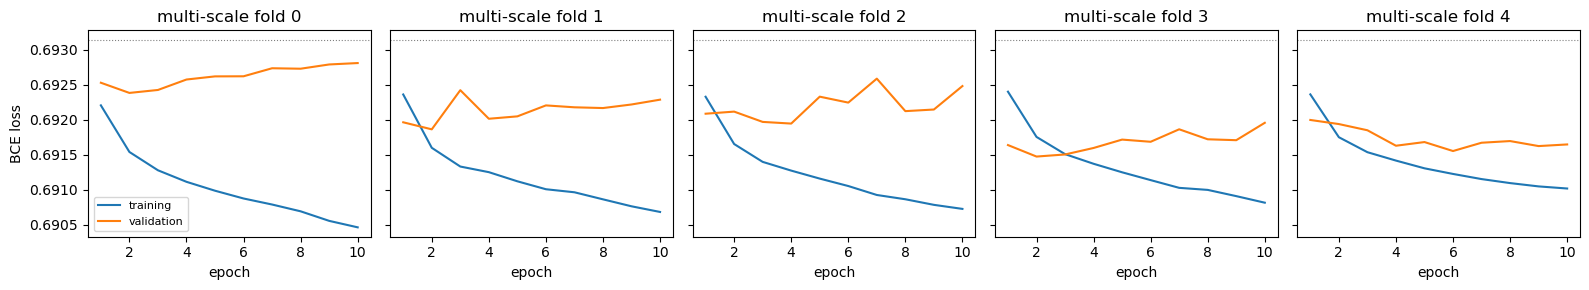

                         model  CV accuracy  fold sd  vs HBM (pts) folds better  paired t
Multi-scale CNN (returns only)       0.5097   0.0017         -1.36          0/5     -10.7


In [ ]:
df_multiscale = summarize(res_multiscale, "Multi-scale CNN (returns only)")
plot_losses(res_multiscale, "multi-scale")
print(compare_to_hbm({"Multi-scale CNN (returns only)": res_nopool}).to_string(index=False))

It might not be (grossly) overfitting but the results are not good. We are well behind the HBM model!
Things started looking exciting at first, but we obtained little to nothing in the end.

### Wrapping up: the CNNs against the HBM

All models use the **same five folds** as the HBM (same reconstruction, same `GroupKFold`), so the comparison is paired fold by fold.

In [ ]:
runs = {"vanilla CNN ": res_vanilla, "volume-aware CNN": res_volume,
        "no-pool CNN(returns only)": res_nopool, "multi-scale CNN (returns only)": res_multiscale}

summary = compare_to_hbm(runs)
print(summary.to_string(index=False))

for name, res in runs.items():
    np.save(f"oof_{name.split()[0]}{'_portfolio' if 'portfolio' in name else ''}.npy", oof_probabilities(res, len(X_train)))

                         model  CV accuracy  fold sd  vs HBM (pts) folds better  paired t
                  vanilla CNN        0.5202   0.0031         -0.32          1/5      -2.4
              volume-aware CNN       0.5152   0.0051         -0.81          0/5      -4.1
     no-pool CNN(returns only)       0.5097   0.0017         -1.36          0/5     -10.7
multi-scale CNN (returns only)       0.5132   0.0022         -1.02          0/5      -8.9


**To wit, the HBM stands and our exploration of CNN failed to produce a better model.**
